In [1]:
!pip install yfinance

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [3]:
stock = "AAPL"

data = yf.download(stock, start="2020-01-01", end="2025-01-01")

data.head()

/tmp/ipykernel_6519/404930100.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(stock, start="2020-01-01", end="2025-01-01")
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.333870,72.394078,71.091176,71.344047,135480400
2020-01-03,71.630661,72.389280,71.406689,71.563228,146322800
2020-01-06,72.201424,72.239958,70.503561,70.754028,118387200
2020-01-07,71.861855,72.466338,71.642697,72.211056,108872000
2020-01-08,73.017845,73.318885,71.565629,71.565629,132079200


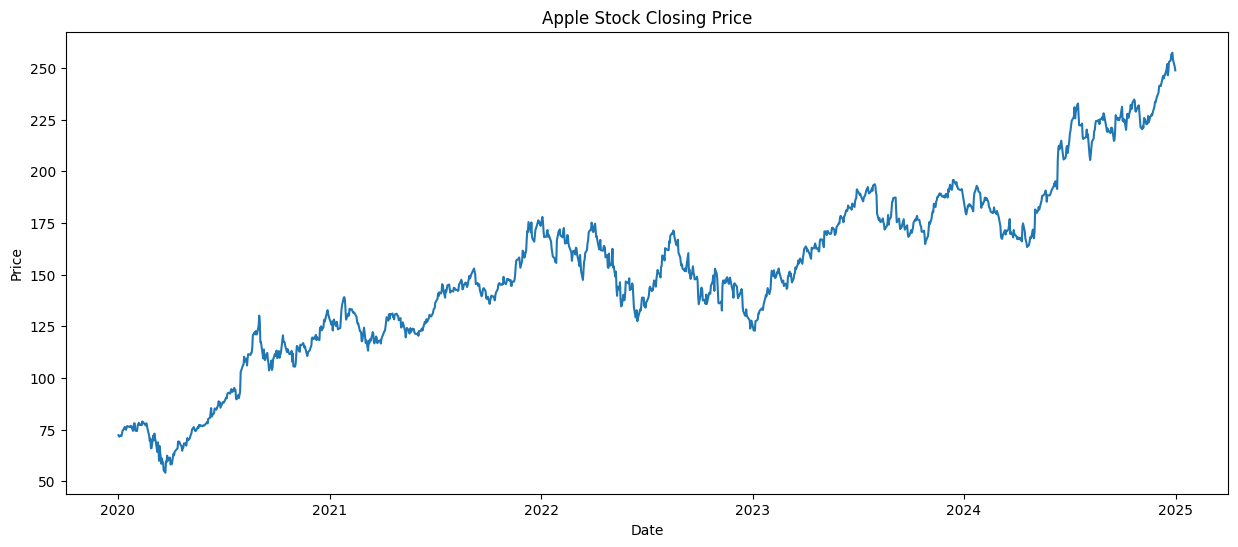

In [4]:
plt.figure(figsize=(15,6))
plt.plot(data['Close'])
plt.title("Apple Stock Closing Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

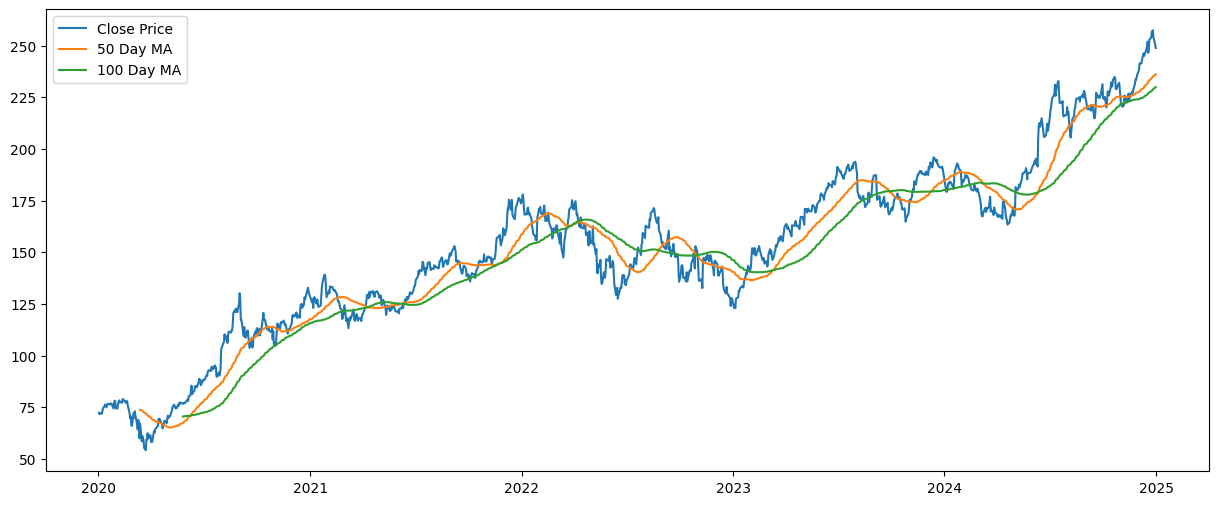

In [5]:
data['MA50'] = data['Close'].rolling(50).mean()
data['MA100'] = data['Close'].rolling(100).mean()

plt.figure(figsize=(15,6))
plt.plot(data['Close'], label='Close Price')
plt.plot(data['MA50'], label='50 Day MA')
plt.plot(data['MA100'], label='100 Day MA')

plt.legend()
plt.show()

In [6]:
data = data[['Close']]

data['Prediction'] = data[['Close']].shift(-30)

data.dropna(inplace=True)

X = np.array(data.drop(['Prediction'], axis=1))
y = np.array(data['Prediction'])

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [8]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [9]:
predictions = model.predict(X_test)

print(predictions[:5])

[150.86990762 165.35334067 128.14844315 159.12859053 224.62861741]


In [10]:
mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("Mean Squared Error:", mse)
print("R2 Score:", r2)

Mean Squared Error: 166.39479874298783
R2 Score: 0.8959805209039362


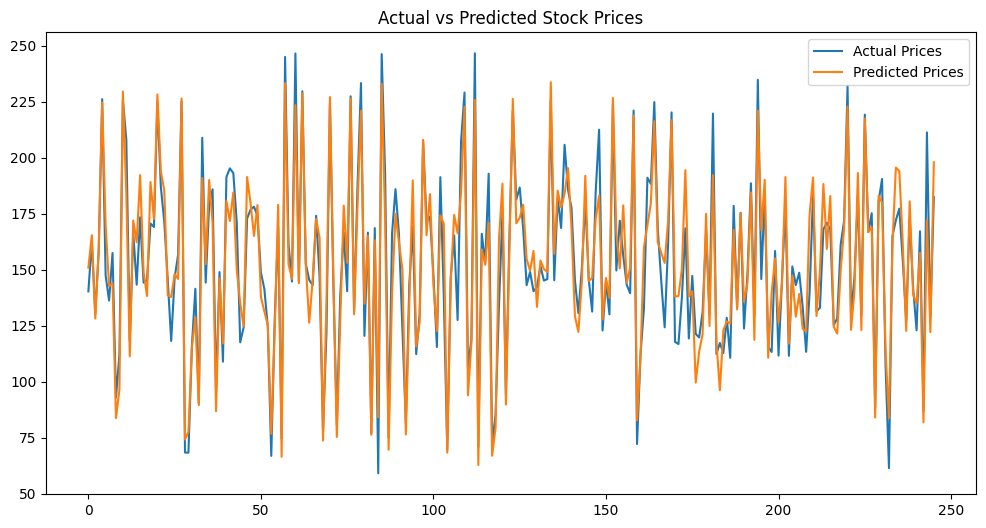

In [11]:
plt.figure(figsize=(12,6))

plt.plot(y_test, label='Actual Prices')
plt.plot(predictions, label='Predicted Prices')

plt.legend()
plt.title("Actual vs Predicted Stock Prices")

plt.show()

In [12]:
future_days = 30

future = data.drop(['Prediction'], axis=1)[-future_days:]

future = np.array(future)

future_prediction = model.predict(future)

print(future_prediction)

[221.72640901 225.63434879 229.24531937 228.76638143 227.3392418
 230.93109963 233.37352702 231.39083646 231.74523227 234.47502832
 235.89261157 235.29876152 230.41384783 230.2318791  231.03644065
 232.94251821 233.20111466 229.78171337 225.76841784 222.89496692
 222.03290514 223.41217454 222.71295401 227.27219991 227.01330897
 224.39555372 224.39555372 225.24897206 228.22149124 225.13388324]
